In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, classification_report

In [44]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\student_depression_dataset.csv")

In [45]:
df.columns = [c.strip() for c in df.columns]

In [46]:
col = "Have you ever had suicidal thoughts ?"
print("Unique raw values:", pd.Series(df[col].values).unique()[:50])

Unique raw values: ['Yes' 'No']


In [47]:
df['Sleep Duration'] = df['Sleep Duration'].astype(str).str.replace("'", "").str.strip().str.lower()
sleep_map = {
    "less than 5 hours": "less than 5",
    "less than 5": "less than 5",
    "5-6 hours": "5-6",
    "5-6": "5-6",
    "7-8 hours": "7-8",
    "7-8": "7-8",
    "more than 8 hours": "more than 8",
    "more than 8": "more than 8"
}
df['Sleep Duration'] = df['Sleep Duration'].replace(sleep_map)

In [48]:
def map_yes_no(series):
    # convert to string, strip and lower to handle different capitalisations and spaces
    s = series.astype(str).str.strip().str.lower()
    # Map known yes/no values; anything else becomes np.nan
    mapped = s.replace({
        'yes': 1, 'y': 1, '1': 1,
        'no': 0, 'n': 0, '0': 0
    })
    # Where strings were 'nan' (string produced by astype) convert to actual np.nan
    mapped = mapped.replace({'nan': np.nan})
    return pd.to_numeric(mapped, errors='coerce')
df[col] = map_yes_no(df[col])
if 'Family History of Mental Illness' in df.columns:
    df['Family History of Mental Illness'] = map_yes_no(df['Family History of Mental Illness'])
print("After mapping unique values:", df[col].unique()[:10])

After mapping unique values: [1 0]


C:\Users\DELL\AppData\Local\Temp\ipykernel_2220\1120798689.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mapped = s.replace({
C:\Users\DELL\AppData\Local\Temp\ipykernel_2220\1120798689.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mapped = s.replace({


In [49]:
numeric_cols = [
    "Age", "Academic Pressure", "Work Pressure", "CGPA",
    "Study Satisfaction", "Job Satisfaction",
    "Work/Study Hours", "Financial Stress", "Depression"
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')


In [50]:
df['Depression'] = pd.to_numeric(df['Depression'], errors='coerce').round().astype('Int64')

In [51]:
text_cols = ['Gender','City','Profession','Dietary Habits','Degree','Sleep Duration']
text_cols = [c for c in text_cols if c in df.columns]

# strip & lowercase text columns (but preserve NaN)
for c in text_cols:
    df[c] = df[c].where(df[c].notna(), np.nan)            # keep NaN as NaN
    df[c] = df[c].astype(str).str.strip().str.lower()
    df[c] = df[c].replace({'nan': np.nan})               # ensure 'nan' strings become actual NaN


In [52]:
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Recompute numeric & categorical columns after cleaning
numeric_cols = [c for c in numeric_cols if c in df.columns]         # keep only present ones
categorical_cols = [c for c in text_cols if c in df.columns]

# Impute numeric (returns numpy array) then assign back with same columns
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

# Impute categorical (most frequent)
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

In [53]:
# 10) Encode ordinal categories
# Sleep Duration ordered mapping (after lowercasing earlier)
sleep_ord_map = {
    "less than 5": 1,
    "5-6": 2,
    "7-8": 3,
    "more than 8": 4
}
if 'Sleep Duration' in df.columns:
    df['Sleep Duration'] = df['Sleep Duration'].map(sleep_ord_map).fillna(0).astype(int)

diet_map = {
    "unhealthy": 1,
    "moderate": 2,
    "healthy": 3
}
if 'Dietary Habits' in df.columns:
    df['Dietary Habits'] = df['Dietary Habits'].map(diet_map).fillna(0).astype(int)

In [54]:
# 11) Encode Gender (binary) safely (male ->1, female ->0)
if 'Gender' in df.columns:
    g = df['Gender'].astype(str).str.strip().str.lower()
    df['Gender'] = g.map({'male':1,'m':1,'female':0,'f':0}).fillna(0).astype(int)

In [55]:
# 12) One-hot encode remaining nominal fields (City, Profession, Degree). Use drop_first=True to avoid multicollinearity.
nominal_cols = [c for c in ['City','Profession','Degree'] if c in df.columns]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

In [56]:
print("\nFinal shape:", df.shape)
print("Any NaNs left?:\n", df.isnull().sum()[df.isnull().sum()>0])
print("Sample head:\n", df.head().T[:60])


Final shape: (27901, 106)
Any NaNs left?:
 Series([], dtype: int64)
Sample head:
                                            0      1      2      3      4
id                                         2      8     26     30     32
Gender                                     1      0      1      0      0
Age                                     33.0   24.0   31.0   28.0   25.0
Academic Pressure                        5.0    2.0    3.0    3.0    4.0
Work Pressure                            0.0    0.0    0.0    0.0    0.0
CGPA                                    8.97    5.9   7.03   5.59   8.13
Study Satisfaction                       2.0    5.0    5.0    2.0    3.0
Job Satisfaction                         0.0    0.0    0.0    0.0    0.0
Sleep Duration                             2      2      1      3      2
Dietary Habits                             3      2      3      2      2
Have you ever had suicidal thoughts ?      1      0      0      1      1
Work/Study Hours                         

In [57]:
print("\nDESCRIBE CATEGORICAL")
cat_cols = df.select_dtypes(include='object')

if cat_cols.shape[1] > 0:
    print(cat_cols.describe())
else:
    print("No categorical columns found.")


DESCRIBE CATEGORICAL
No categorical columns found.


In [58]:
# 📌 EXPLORATORY DATA ANALYSIS

print("\n===== SHAPE =====")
print(df.shape)

print("\n===== COLUMNS =====")
print(df.columns.tolist())

print("\n===== DATA TYPES =====")
print(df.dtypes)

print("\n===== INFO =====")
print(df.info())

print("\n===== FIRST 5 ROWS =====")
print(df.head())

print("\n===== LAST 5 ROWS =====")
print(df.tail())

print("\n===== RANDOM SAMPLE (5 rows) =====")
print(df.sample(5))

print("\n===== DESCRIBE NUMERIC =====")
print(df.describe())

print("\n===== DESCRIBE CATEGORICAL =====")
cat_cols = df.select_dtypes(include='object')
if cat_cols.shape[1] > 0:
    print(cat_cols.describe())
else:
    print("No categorical columns found.")

print("\n===== UNIQUE VALUES PER COLUMN =====")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

print("\n===== DUPLICATE ROWS =====")
print(df.duplicated().sum())

print("\n===== MISSING VALUES PER COLUMN =====")
print(df.isnull().sum())

print("\n===== TARGET VALUE COUNTS (Depression) =====")
if "Depression" in df.columns:
    print(df["Depression"].value_counts())
else:
    print("Column 'Depression' not found.")


===== SHAPE =====
(27901, 106)

===== COLUMNS =====
['id', 'Gender', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression', "City_'less than 5 kalyan'", 'City_3.0', 'City_agra', 'City_ahmedabad', 'City_bangalore', 'City_bhavna', 'City_bhopal', 'City_chennai', 'City_city', 'City_delhi', 'City_faridabad', 'City_gaurav', 'City_ghaziabad', 'City_harsh', 'City_harsha', 'City_hyderabad', 'City_indore', 'City_jaipur', 'City_kalyan', 'City_kanpur', 'City_khaziabad', 'City_kibara', 'City_kolkata', 'City_lucknow', 'City_ludhiana', 'City_m.com', 'City_m.tech', 'City_me', 'City_meerut', 'City_mihir', 'City_mira', 'City_mumbai', 'City_nagpur', 'City_nalini', 'City_nalyan', 'City_nandini', 'City_nashik', 'City_patna', 'City_pune', 'City_rajkot', 'City_rashi', 'City_reyansh', 'City_saanvi', 'City

In [59]:
#sns.set(style="whitegrid", palette="pastel", font_scale=1.1)
#plt.rcParams['figure.figsize'] = (10, 5)

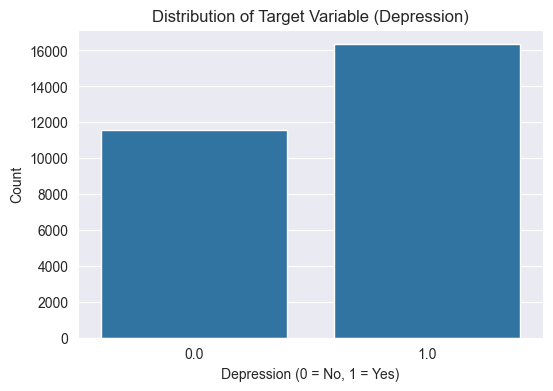

In [60]:
# TARGET VARIABLE DISTRIBUTION
plt.figure(figsize=(6,4))
sns.countplot(x=df['Depression'])
plt.title("Distribution of Target Variable (Depression)")
plt.xlabel("Depression (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

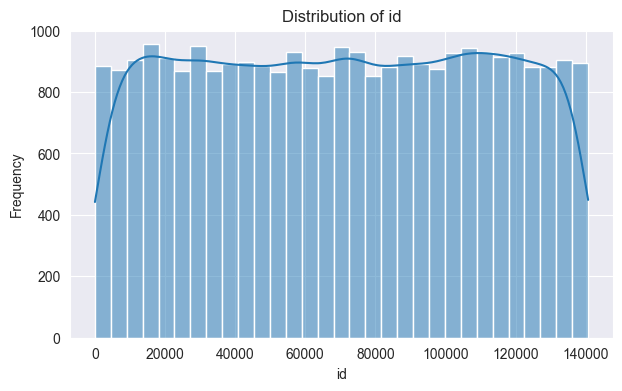

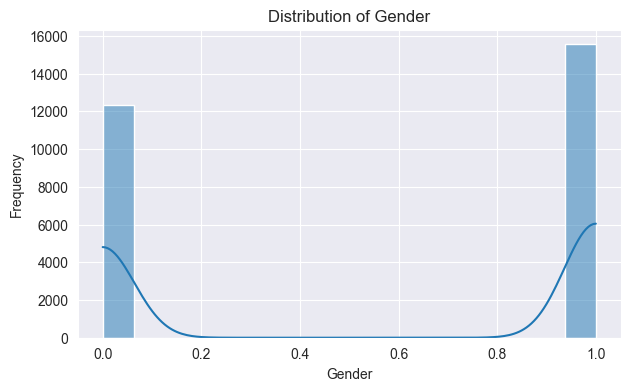

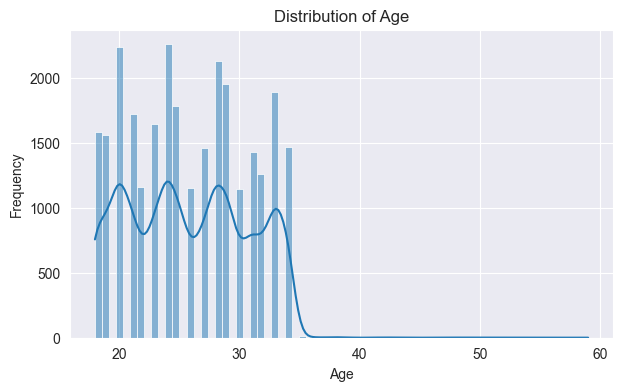

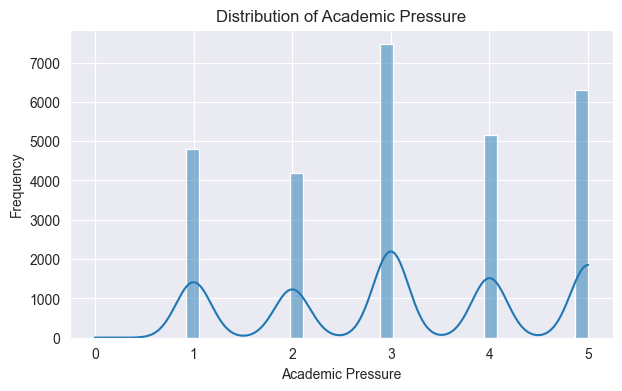

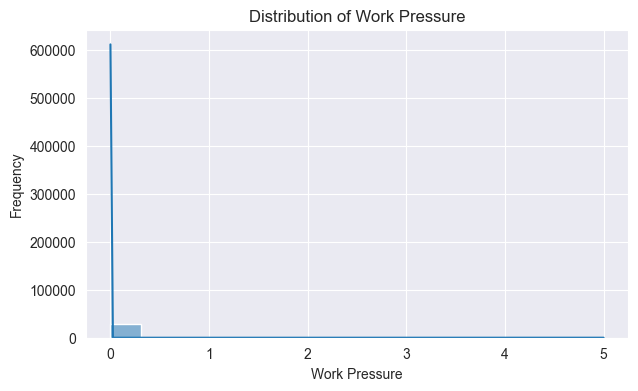

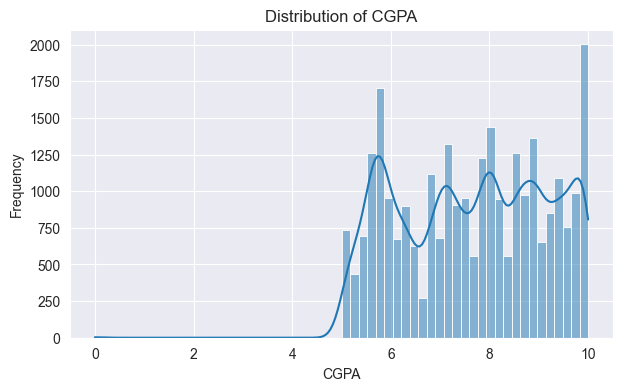

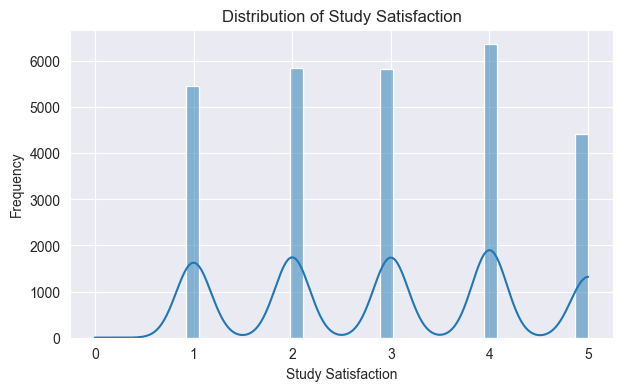

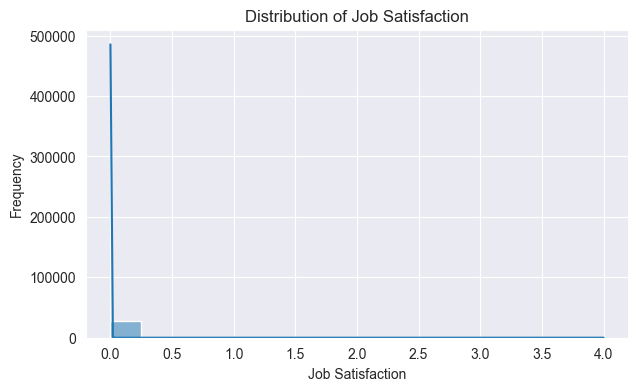

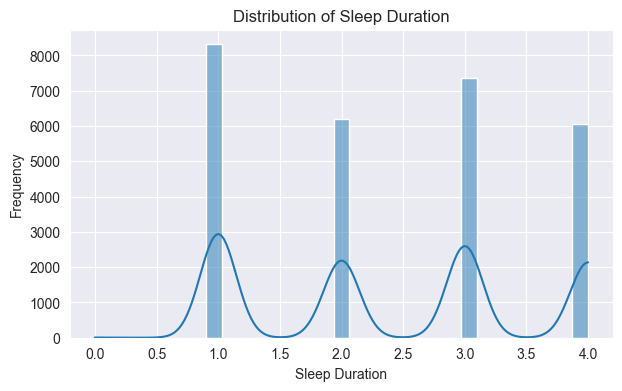

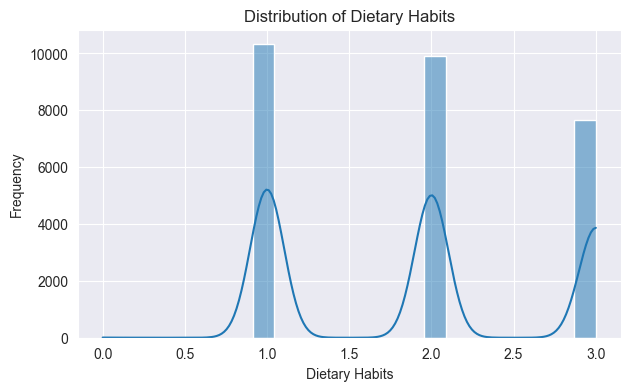

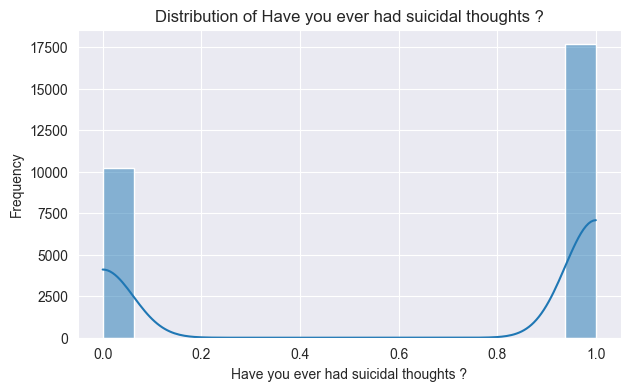

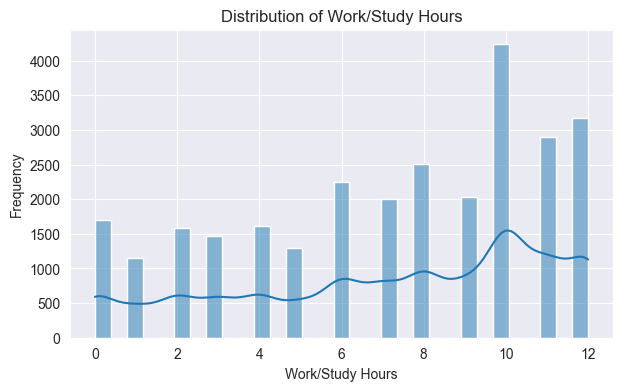

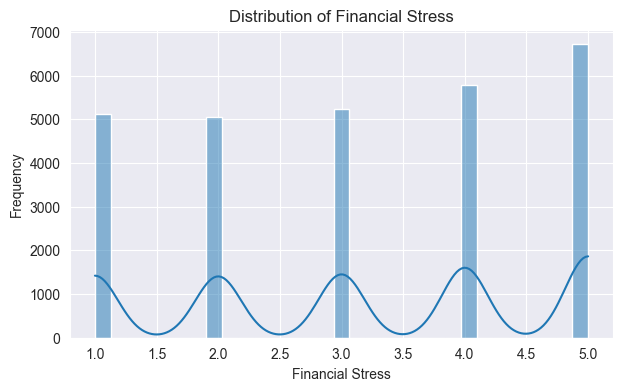

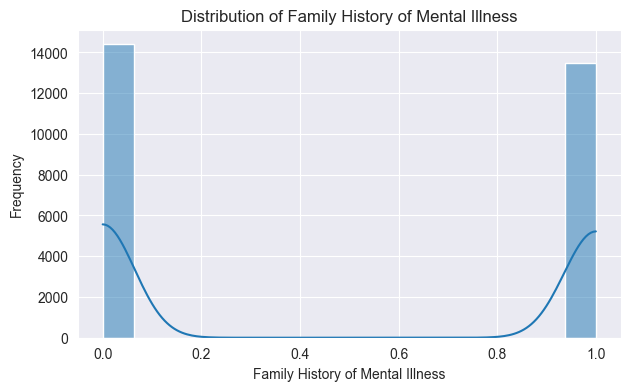

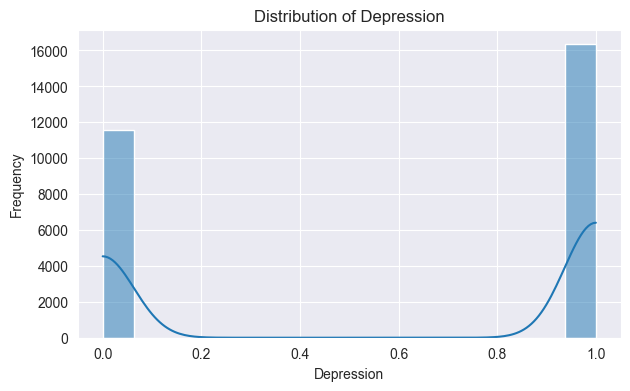

In [61]:
# NUMERIC COLUMN DISTRIBUTIONS (HISTOGRAMS)
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

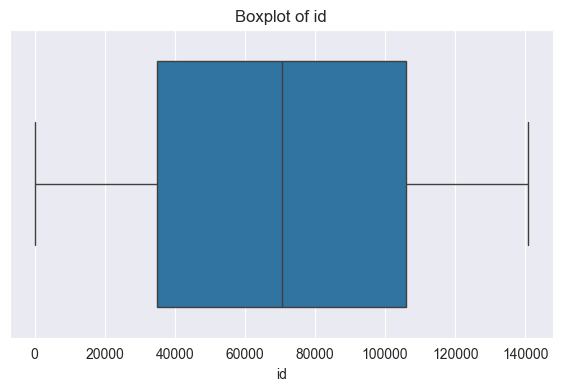

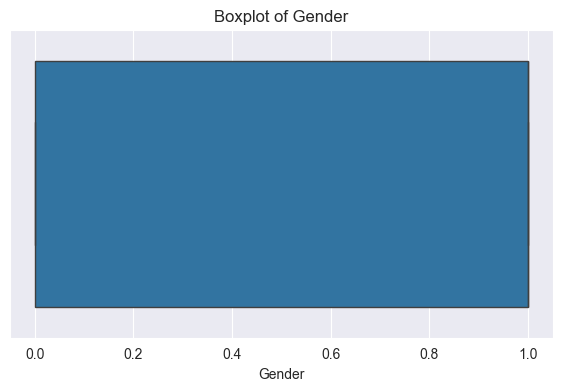

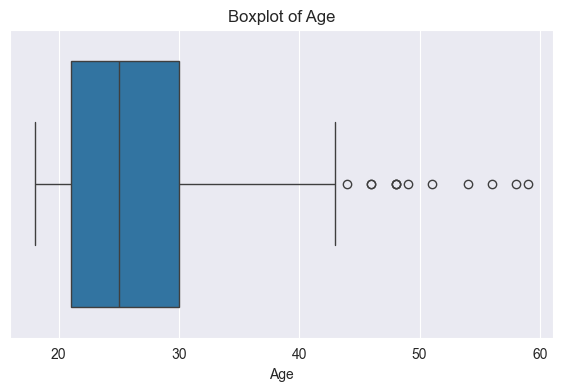

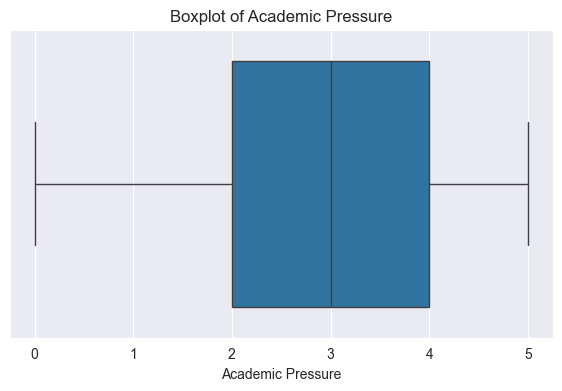

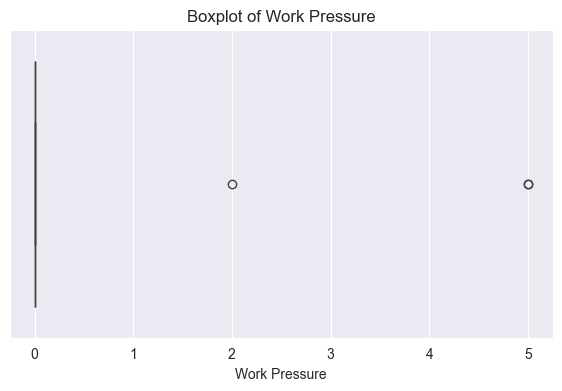

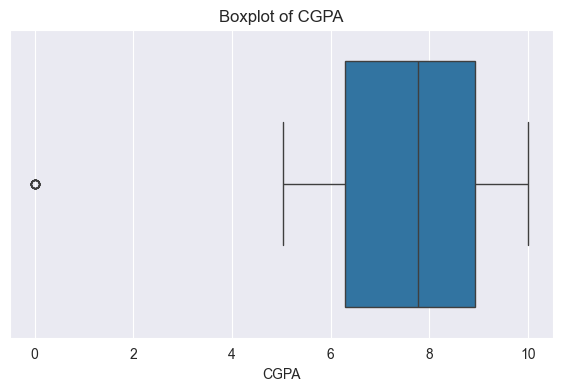

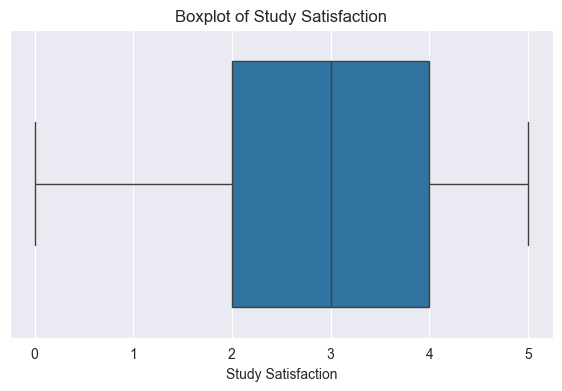

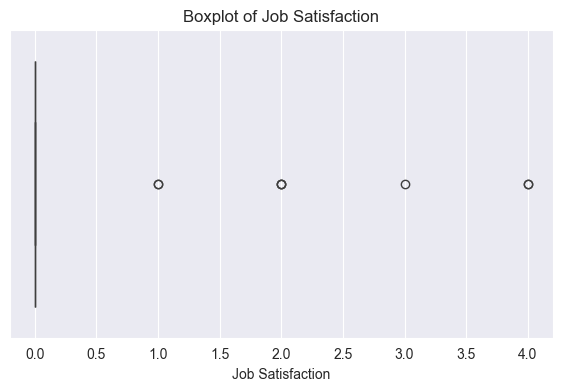

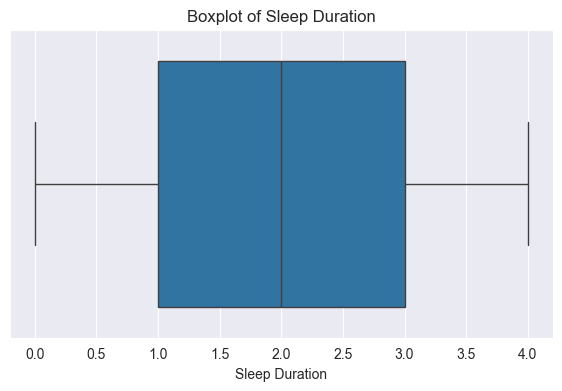

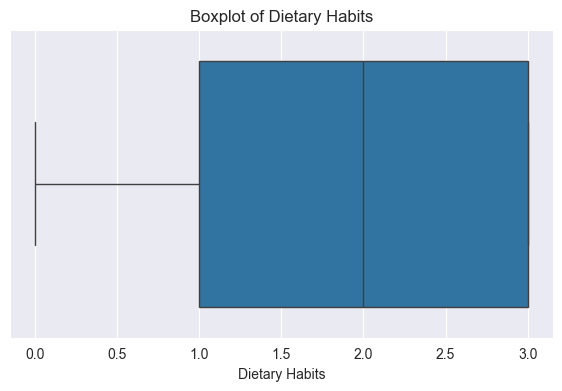

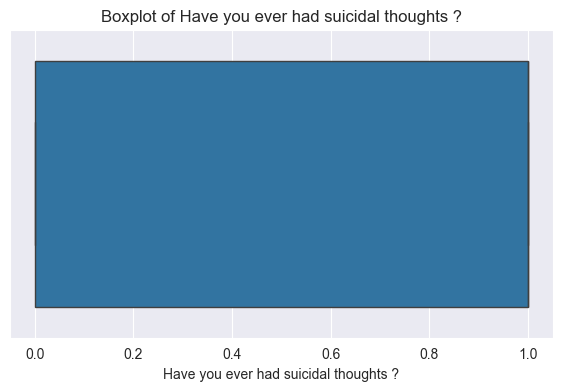

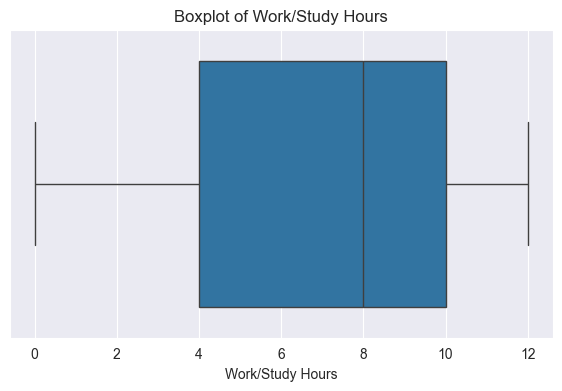

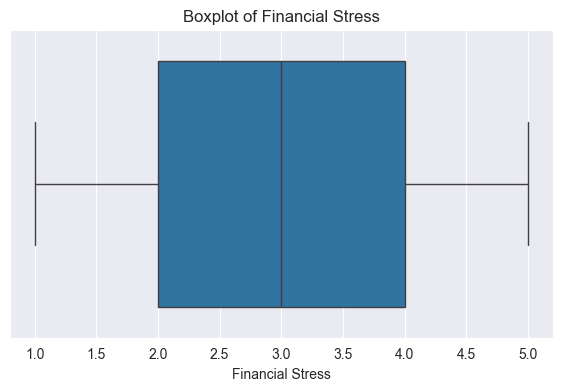

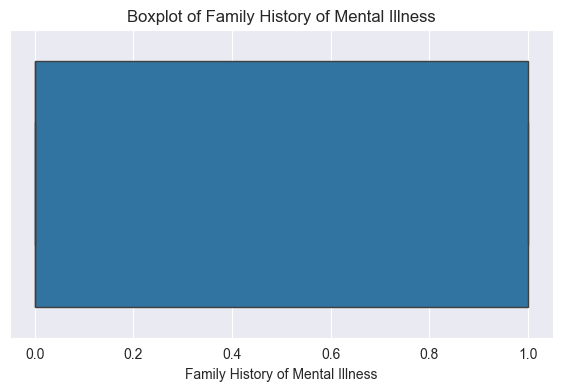

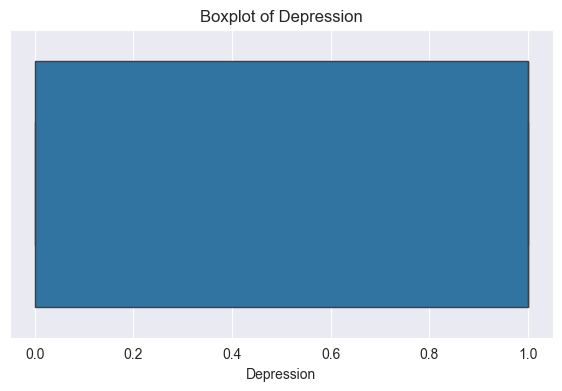

In [62]:
# BOX PLOTS FOR NUMERIC (DETECT OUTLIERS)
for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

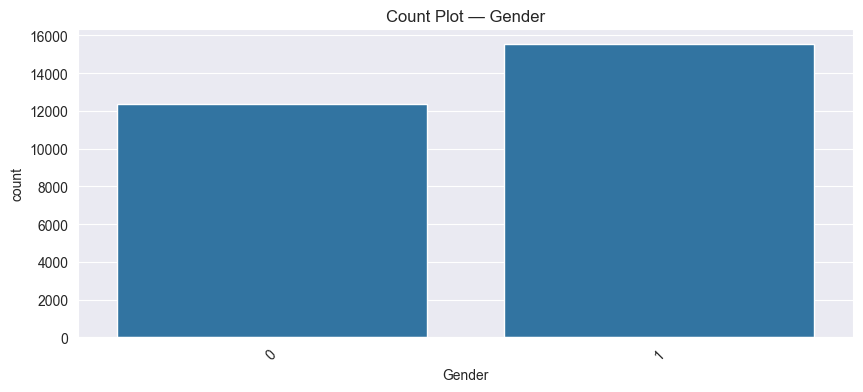

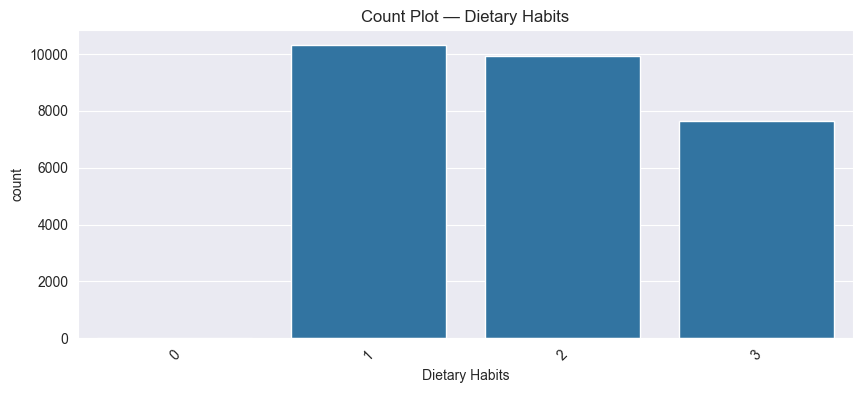

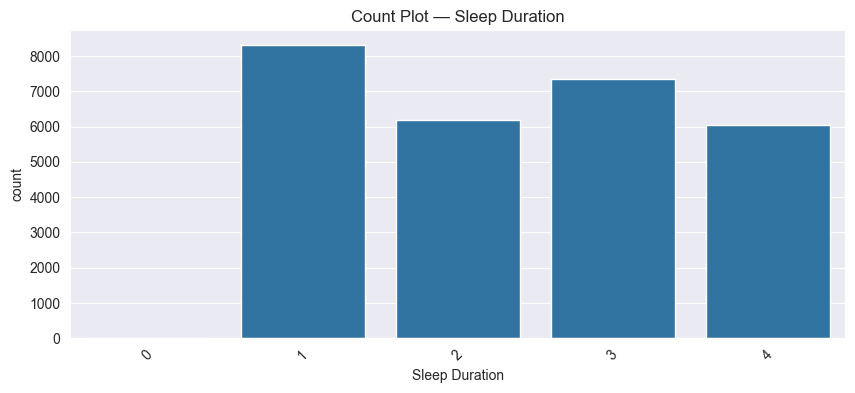

In [63]:
# COUNT PLOTS FOR CATEGORICAL FEATURES
categorical_cols = ["Gender", "City", "Profession", "Dietary Habits", "Degree", "Sleep Duration"]

existing_cat_cols = [col for col in categorical_cols if col in df.columns]

for col in existing_cat_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(x=df[col])
    plt.title(f"Count Plot — {col}")
    plt.xticks(rotation=45)
    plt.show()

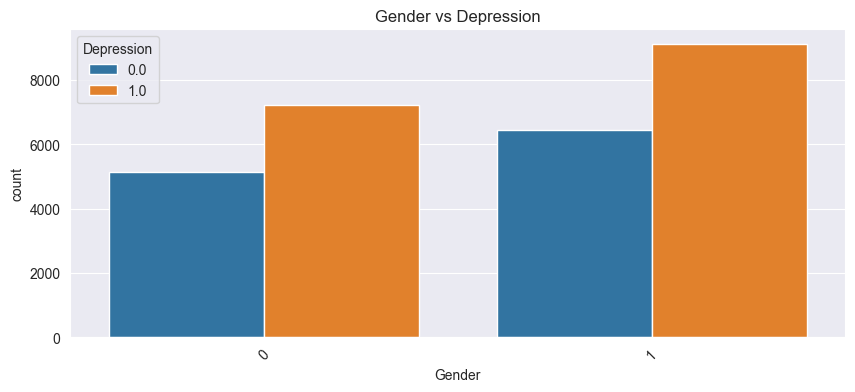

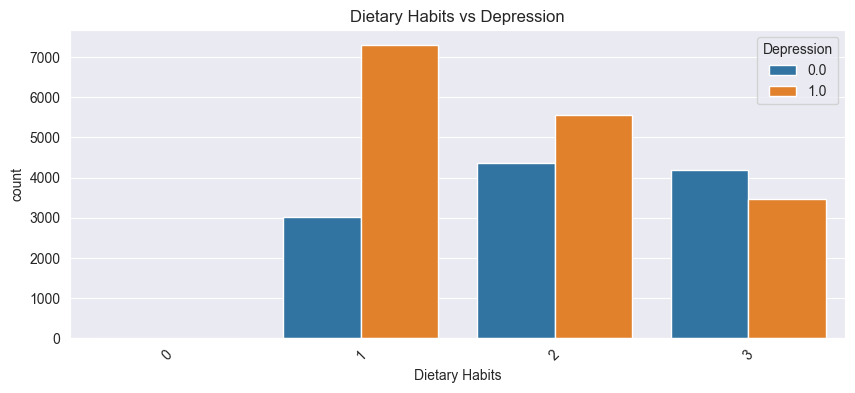

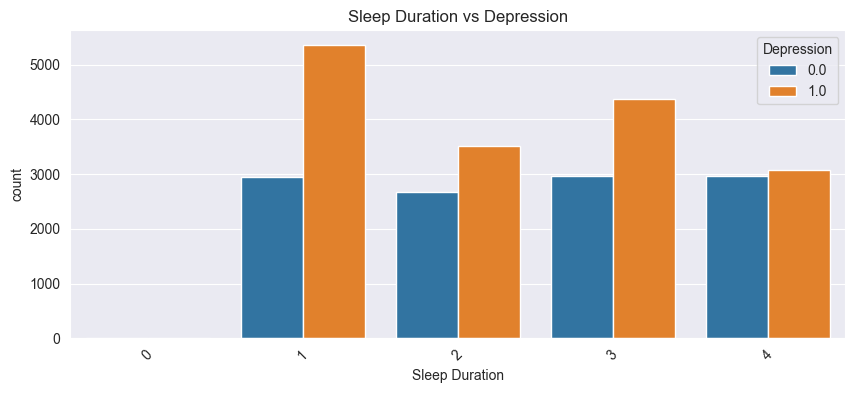

In [64]:
# CATEGORICAL VS TARGET
for col in existing_cat_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(x=df[col], hue=df["Depression"])
    plt.title(f"{col} vs Depression")
    plt.xticks(rotation=45)
    plt.show()

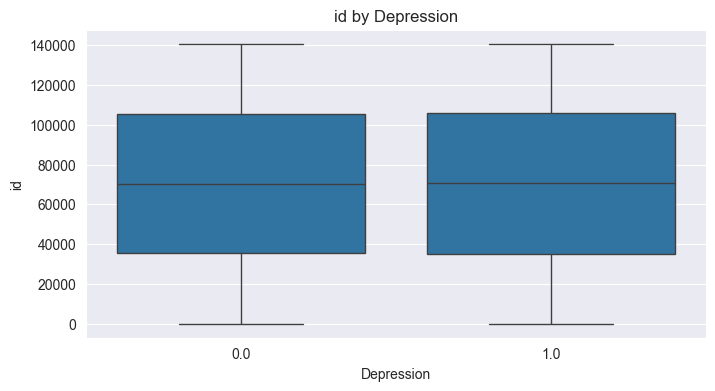

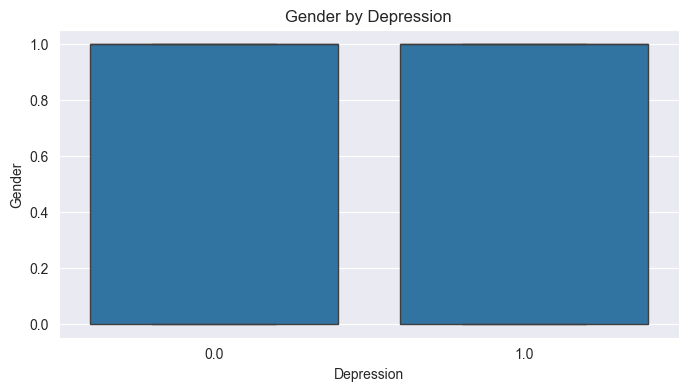

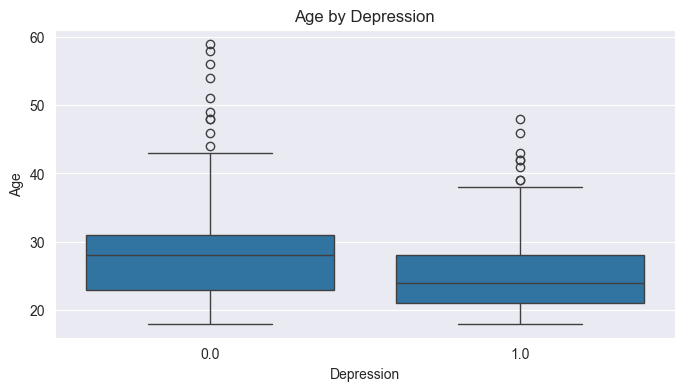

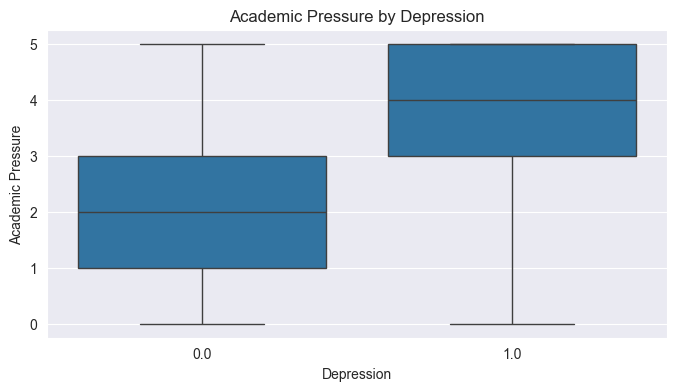

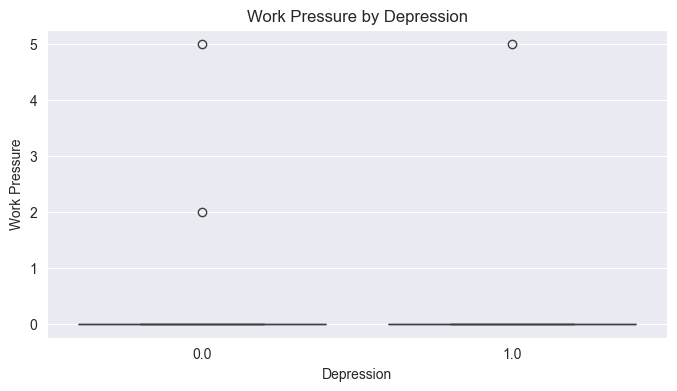

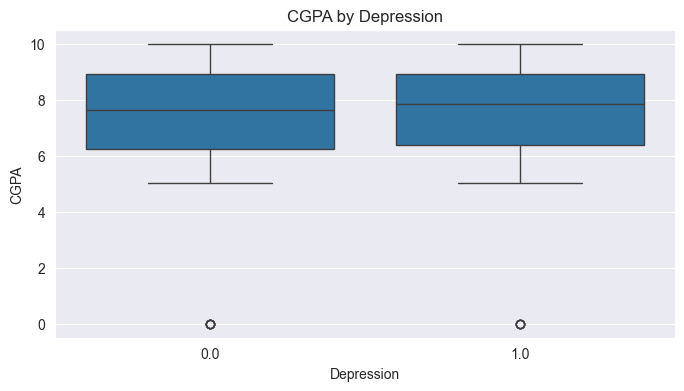

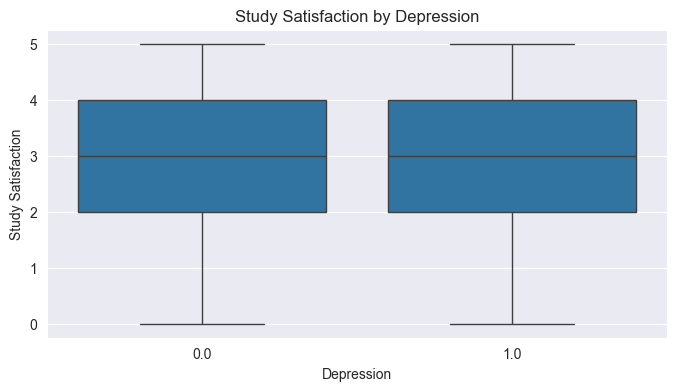

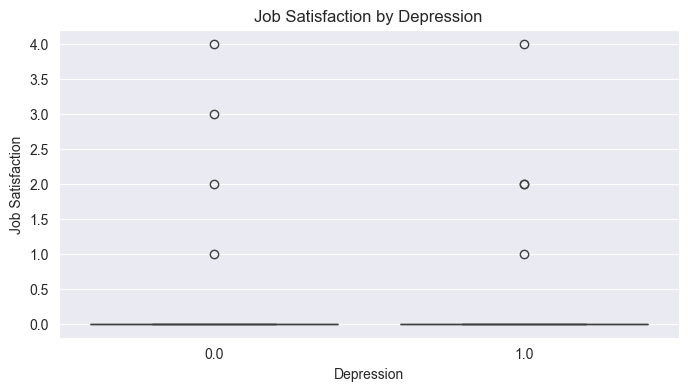

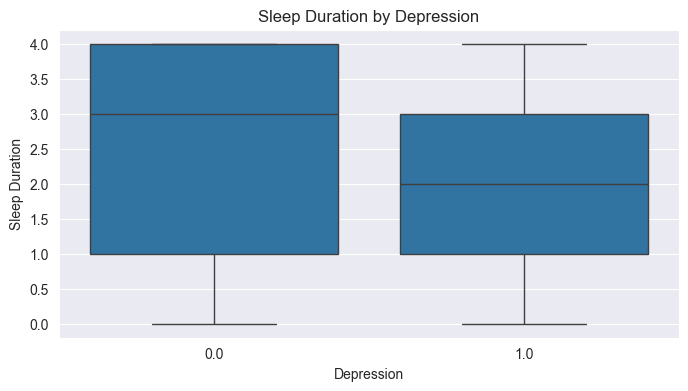

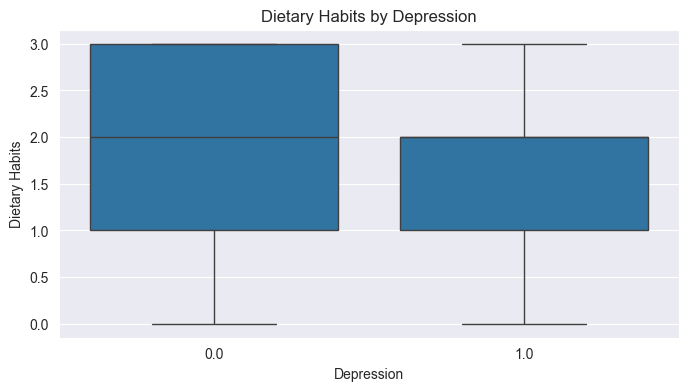

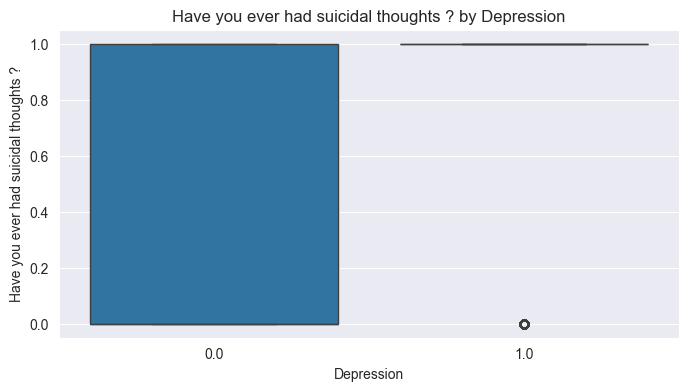

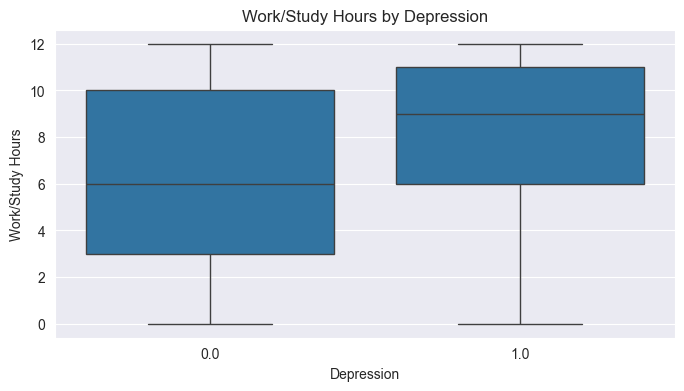

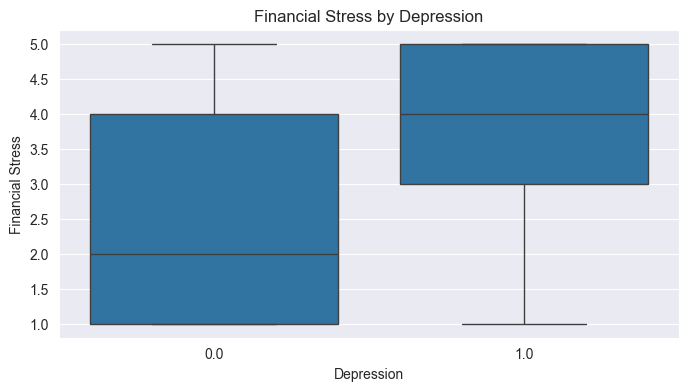

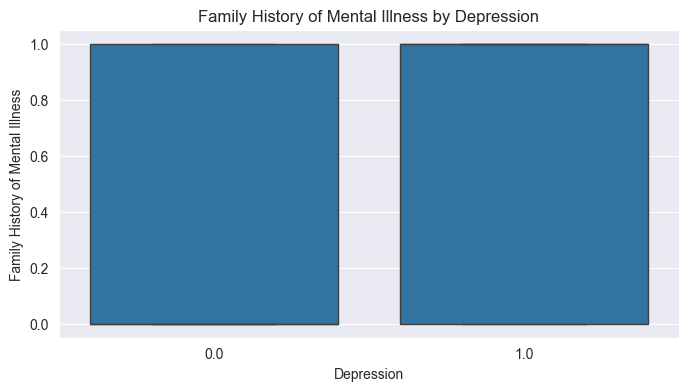

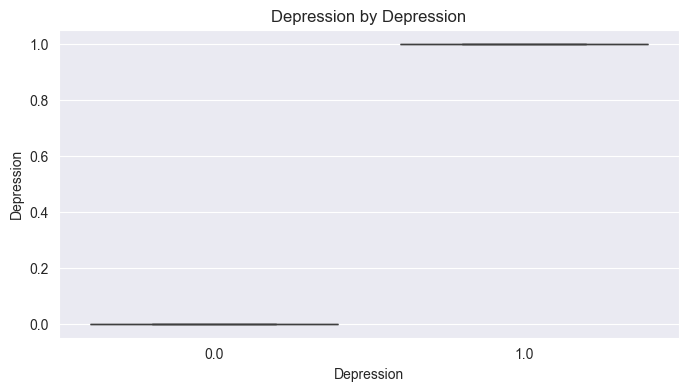

In [65]:
# NUMERIC VS TARGET (BOXPLOT)
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df["Depression"], y=df[col])
    plt.title(f"{col} by Depression")
    plt.xlabel("Depression")
    plt.ylabel(col)
    plt.show()

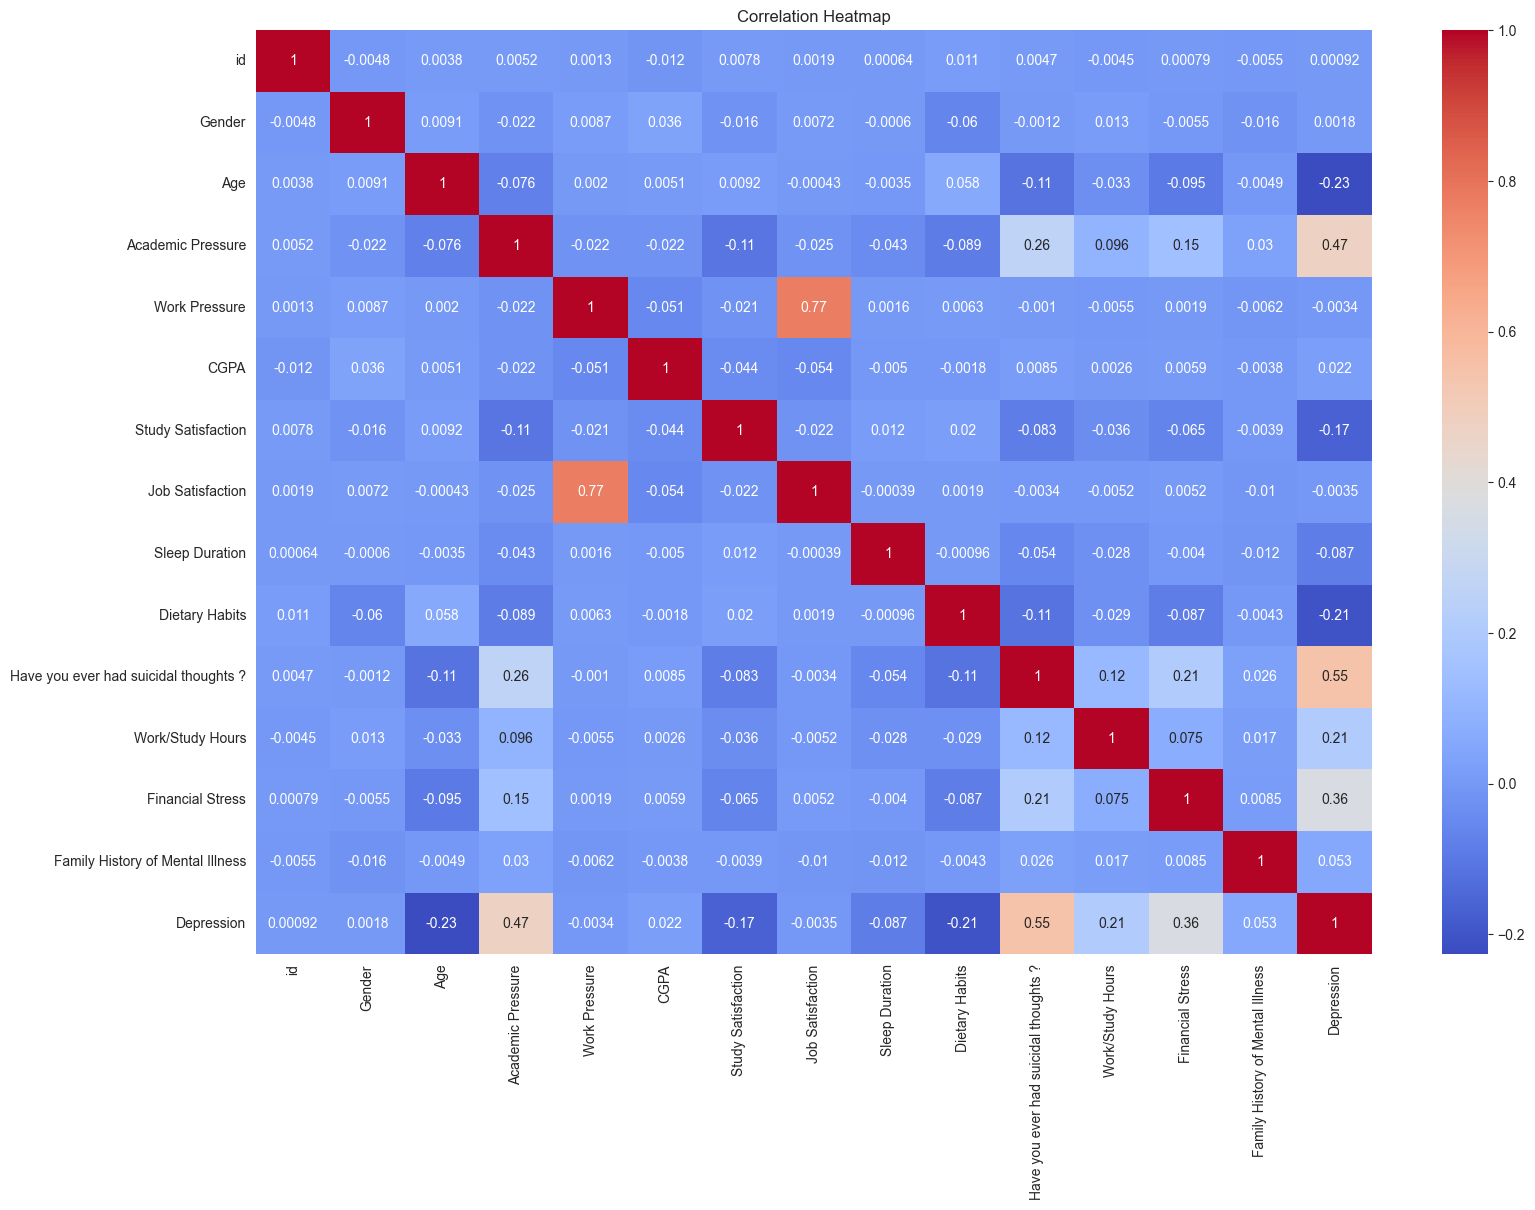

In [66]:
# CORRELATION HEATMAP
cols = numeric_cols + ['Depression']
cols = pd.Index(cols).drop_duplicates().tolist()

plt.figure(figsize=(18,12))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

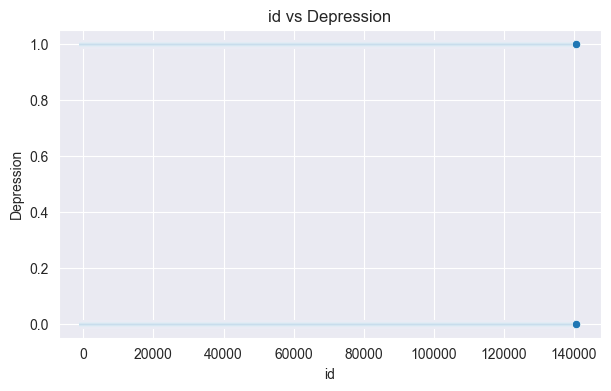

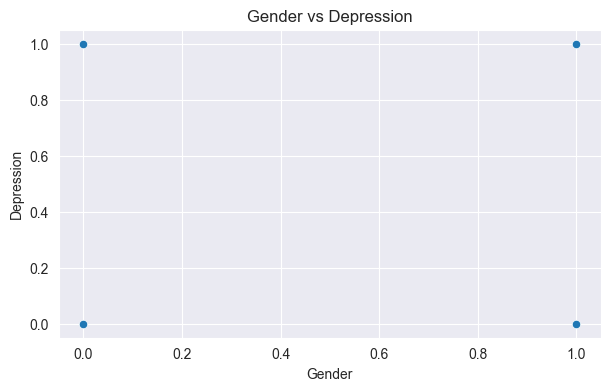

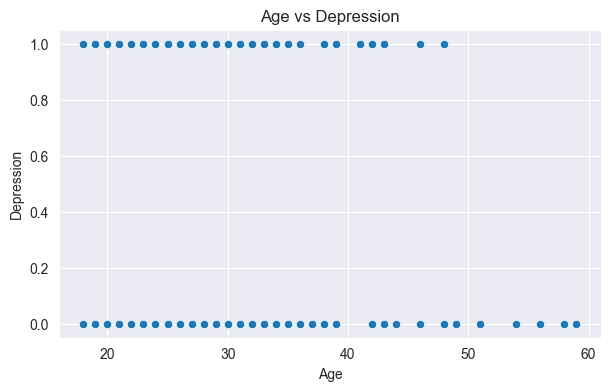

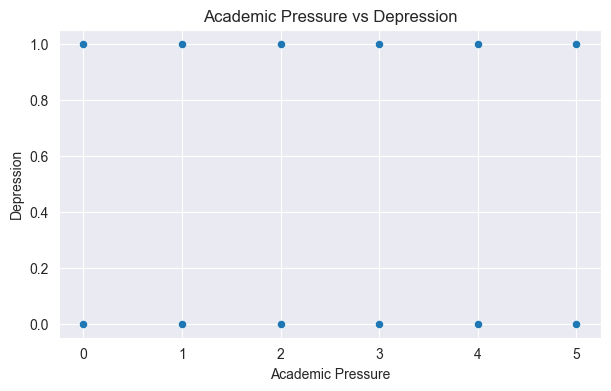

In [67]:
# FEATURE RELATIONSHIP (SCATTERPLOTS)
if len(numeric_cols) >= 2:
    for col in numeric_cols[:4]:  # Limit to first 4 numeric columns
        plt.figure(figsize=(7,4))
        sns.scatterplot(x=df[col], y=df["Depression"])
        plt.title(f"{col} vs Depression")
        plt.show()

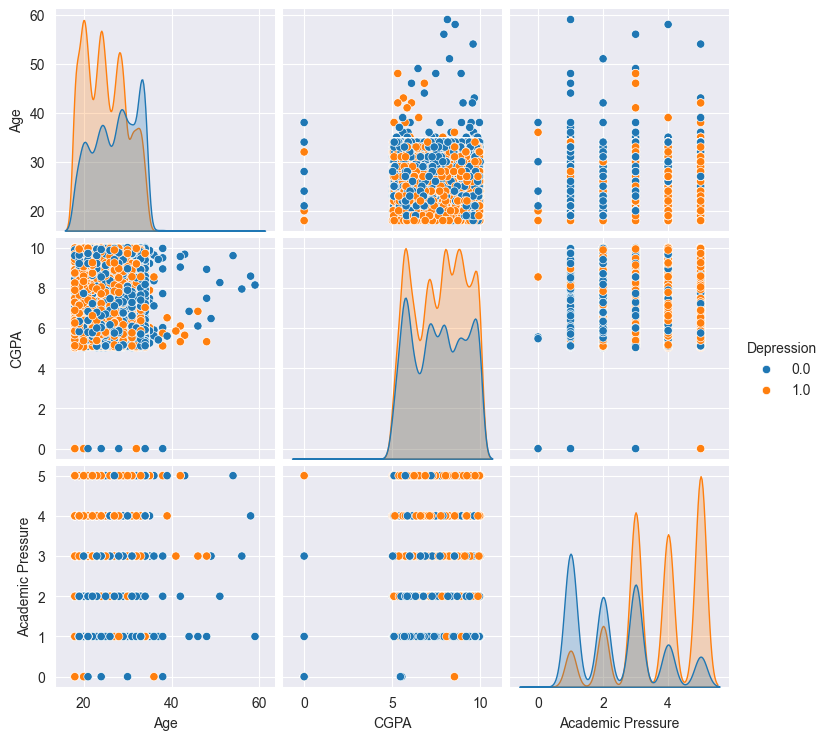

In [68]:
small_df = df[["Age", "CGPA", "Academic Pressure", "Depression"]]
sns.pairplot(small_df, hue="Depression")
plt.show()

In [69]:
categorical_cols = ["Gender", "City", "Profession", "Dietary Habits", "Degree", "Sleep Duration"]

for col in categorical_cols:
    if col not in df.columns:
        print("MISSING:", col)

MISSING: City
MISSING: Profession
MISSING: Degree


In [70]:
df = pd.get_dummies(df, drop_first=True)

In [71]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Age'] >= Q1 - 1.5*IQR) & (df['Age'] <= Q3 + 1.5*IQR)]

In [72]:
df.corr()['Depression'].sort_values()

Age                                     -0.225820
Dietary Habits                          -0.206787
Study Satisfaction                      -0.168018
Sleep Duration                          -0.086694
Degree_m.tech                           -0.030049
                                           ...   
Work/Study Hours                         0.208505
Financial Stress                         0.363788
Academic Pressure                        0.474851
Have you ever had suicidal thoughts ?    0.546537
Depression                               1.000000
Name: Depression, Length: 106, dtype: float64

In [73]:
X = df.drop('Depression', axis=1)
y = df['Depression']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [74]:
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

In [75]:
models = {'Decision Tree': dt, 'Random Forest': rf, 'XGBoost': xgb}

In [76]:
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # For ROC-AUC
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    
    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'ROC-AUC': roc_auc, 'Confusion Matrix': cm}
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print("Confusion Matrix:")
    print(cm)


Training Decision Tree...
Accuracy: 0.7721
Precision: 0.8106
Recall: 0.7980
F1-Score: 0.8043
ROC-AUC: 0.7667
Confusion Matrix:
[[1696  610]
 [ 661 2611]]

Training Random Forest...
Accuracy: 0.8387
Precision: 0.8488
Recall: 0.8820
F1-Score: 0.8651
ROC-AUC: 0.9131
Confusion Matrix:
[[1792  514]
 [ 386 2886]]

Training XGBoost...


C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [07:23:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.8358
Precision: 0.8506
Recall: 0.8735
F1-Score: 0.8619
ROC-AUC: 0.9092
Confusion Matrix:
[[1804  502]
 [ 414 2858]]


In [77]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [78]:
lr = LogisticRegression(random_state=42)
svm = SVC(probability=True, random_state=42)  # probability=True needed for ROC-AUC
knn = KNeighborsClassifier()

In [79]:
scaled_models = {'Logistic Regression': lr, 'SVM': svm, 'KNN': knn}

In [80]:
scaled_results = {}

for name, model in scaled_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]  # ROC-AUC
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    
    scaled_results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'ROC-AUC': roc_auc, 'Confusion Matrix': cm}
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print("Confusion Matrix:")
    print(cm)


Training Logistic Regression...
Accuracy: 0.8446
Precision: 0.8571
Recall: 0.8820
F1-Score: 0.8694
ROC-AUC: 0.9177
Confusion Matrix:
[[1825  481]
 [ 386 2886]]

Training SVM...
Accuracy: 0.8428
Precision: 0.8523
Recall: 0.8854
F1-Score: 0.8685
ROC-AUC: 0.9139
Confusion Matrix:
[[1804  502]
 [ 375 2897]]

Training KNN...
Accuracy: 0.7359
Precision: 0.7445
Recall: 0.8371
F1-Score: 0.7881
ROC-AUC: 0.7967
Confusion Matrix:
[[1366  940]
 [ 533 2739]]


In [81]:
all_results = {**results, **scaled_results}  # merge dictionaries
summary = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
for model_name, metrics in all_results.items():
    summary = pd.concat([summary, pd.DataFrame({
        'Model': [model_name],
        'Accuracy': [metrics['Accuracy']],
        'Precision': [metrics['Precision']],
        'Recall': [metrics['Recall']],
        'F1-Score': [metrics['F1-Score']],
        'ROC-AUC': [metrics['ROC-AUC']]
    })], ignore_index=True)
print(" Model Comparison Summary ")
print(summary.sort_values(by='F1-Score', ascending=False))  # sorted by F1-score


 Model Comparison Summary 
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
3  Logistic Regression  0.844568   0.857143  0.882029  0.869408  0.917687
4                  SVM  0.842775   0.852310  0.885391  0.868535  0.913873
1        Random Forest  0.838652   0.848824  0.882029  0.865108  0.913108
2              XGBoost  0.835783   0.850595  0.873472  0.861882  0.909228
0        Decision Tree  0.772141   0.810618  0.797983  0.804251  0.766728
5                  KNN  0.735927   0.744496  0.837103  0.788088  0.796699


C:\Users\DELL\AppData\Local\Temp\ipykernel_2220\3490683077.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary = pd.concat([summary, pd.DataFrame({


In [82]:
for model_name, metrics in all_results.items():
    print(f"\n Classification Report: {model_name} ")
    if model_name in scaled_models:
        y_pred = scaled_models[model_name].predict(X_test_scaled)
    else:
        y_pred = models[model_name].predict(X_test)
    
    print(classification_report(y_test, y_pred))


 Classification Report: Decision Tree 
              precision    recall  f1-score   support

         0.0       0.72      0.74      0.73      2306
         1.0       0.81      0.80      0.80      3272

    accuracy                           0.77      5578
   macro avg       0.77      0.77      0.77      5578
weighted avg       0.77      0.77      0.77      5578


 Classification Report: Random Forest 
              precision    recall  f1-score   support

         0.0       0.82      0.78      0.80      2306
         1.0       0.85      0.88      0.87      3272

    accuracy                           0.84      5578
   macro avg       0.84      0.83      0.83      5578
weighted avg       0.84      0.84      0.84      5578


 Classification Report: XGBoost 
              precision    recall  f1-score   support

         0.0       0.81      0.78      0.80      2306
         1.0       0.85      0.87      0.86      3272

    accuracy                           0.84      5578
   macro avg  

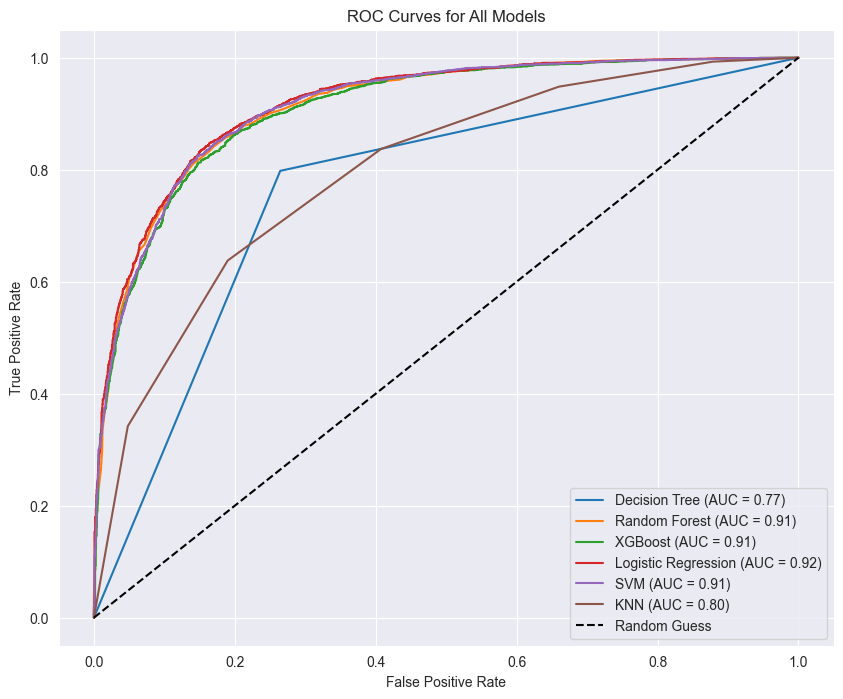

In [83]:
plt.figure(figsize=(10, 8))
# Plot ROC for non-scaled models
for model_name in results:
    y_prob = models[model_name].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
# Plot ROC for scaled models
for model_name in scaled_results:
    y_prob = scaled_models[model_name].predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
# Diagonal line for reference
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.title('ROC Curves for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

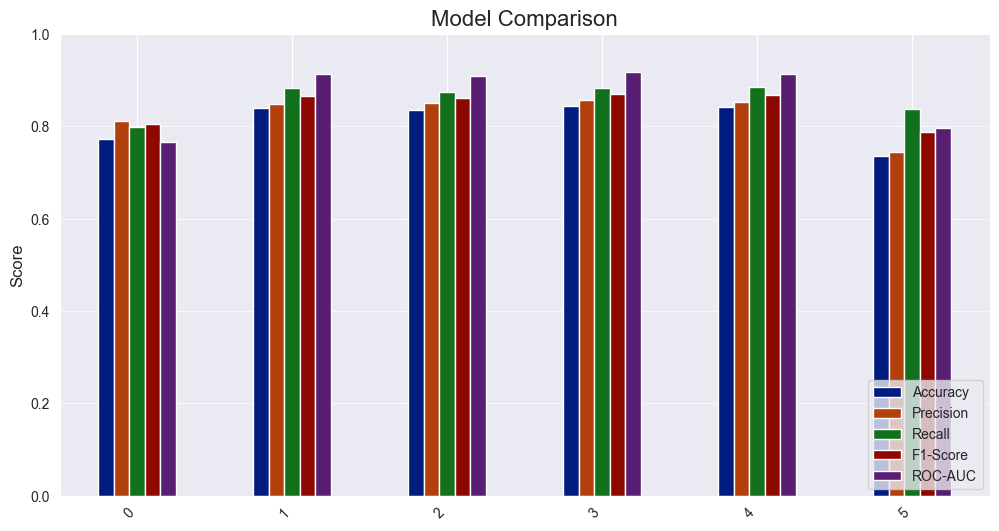

In [84]:
sns.set_style("darkgrid")
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

# Dark palette
dark_colors = sns.color_palette("dark", n_colors=len(metrics_to_plot))

# Plot grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))
summary[metrics_to_plot].plot(kind='bar', ax=ax, color=dark_colors)

# Set x-ticks to model names
ax.set_xticks(np.arange(len(summary.index)))
ax.set_xticklabels(summary.index, rotation=45, ha='right', fontsize=10)

plt.title('Model Comparison', fontsize=16)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1)
plt.legend(loc='lower right', fontsize=10)
plt.grid(axis='y', alpha=0.7)
plt.show()
